# Periodic Ising Model Generator

This notebook builds on `XYModel/ising.py` to simulate the classical Ising model on hyper-rectangular lattices of arbitrary shape using periodic boundary conditions. Specify the number of sites along each axis, temperature, and sampling schedule to obtain spin configurations plus thermodynamic observables for downstream experiments.

## Notebook goals
- Provide a reusable Metropolis sampler that enforces periodic boundary conditions along every axis.
- Demonstrate how to request arbitrary lattice shapes (square, rectangular, or higher-dimensional grids).
- Visualize representative spin configurations and track magnetization / energy density across samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from ising import (
    IsingModelMetropolisSimulation,
    build_ising_dataset,
    generate_ising_snapshots,
)

plt.style.use('seaborn-v0_8-darkgrid')

### Helper utilities
The helpers below keep the rest of the notebook tidy by standardizing how snapshots and observables are displayed.

In [2]:
def visualize_spin_configuration(config, ax=None, title=None):
    """Plot a 2D spin configuration with +/-1 colors."""
    if config.ndim != 2:
        raise ValueError("Visualization only supports 2D lattices; reshape or select a plane.")
    ax = ax or plt.gca()
    im = ax.imshow(config, cmap='coolwarm', vmin=-1, vmax=1, origin='lower')
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax


def plot_observables(run_data, suptitle=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(run_data['magnetization'], marker='o')
    axes[0].set_ylabel('Magnetization per spin')
    axes[0].set_xlabel('Sample index')
    axes[1].plot(run_data['energy_density'], marker='o', color='tab:red')
    axes[1].set_ylabel('Energy density')
    axes[1].set_xlabel('Sample index')
    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout()
    return fig, axes


def describe_run(run_data):
    shape = run_data['snapshots'].shape
    print(f"Snapshots array shape: {shape} (n_samples, *lattice_shape)")
    print(f"Mean magnetization: {run_data['magnetization'].mean():.3f}")
    print(f"Mean energy density: {run_data['energy_density'].mean():.3f}")


## Example 1: Square lattice (64x64)
A near-critical run at \(T/J = 2.2\) shows fluctuating magnetization while preserving periodic boundary conditions along both axes.

In [15]:
square_params = dict(
    lattice_shape=(64, 64),
    temperature=2.0,
    n_samples=2,
    burn_in_sweeps=5000,
    sweeps_per_sample=50,
    random_state=0,
)

square_run = generate_ising_snapshots(**square_params)
describe_run(square_run)


Snapshots array shape: (2, 64, 64) (n_samples, *lattice_shape)
Mean magnetization: 0.910
Mean energy density: -1.735


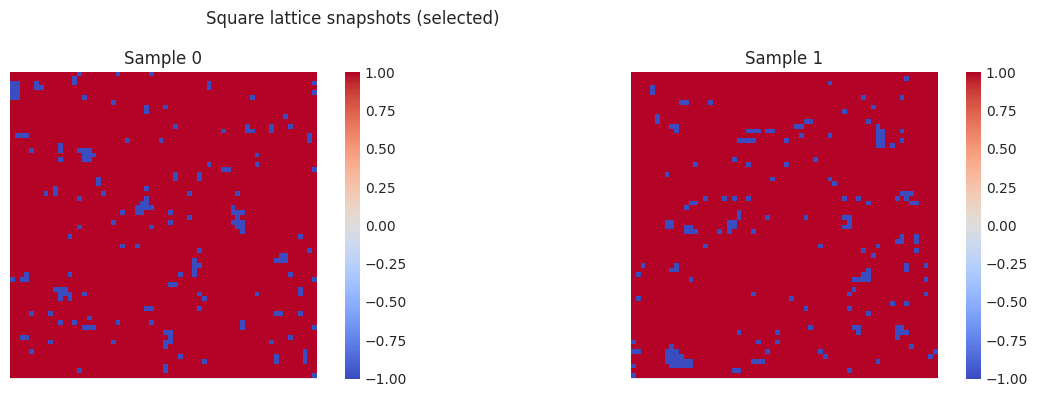

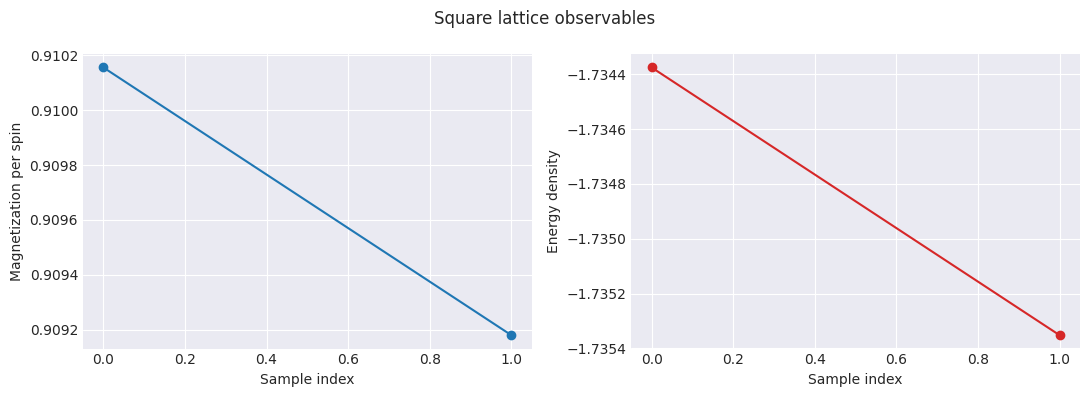

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for idx, ax in enumerate(axes):
    visualize_spin_configuration(square_run['snapshots'][idx], ax=ax, title=f'Sample {idx}')
fig.suptitle('Square lattice snapshots (selected)')
fig.tight_layout()
plt.show()

plot_observables(square_run, suptitle='Square lattice observables')
plt.show()


## Example 2: Rectangular lattice (32x96)
Change `lattice_shape` to any desired 2D rectangle to reuse the same sampler. All axes inherit periodic boundary conditions automatically.

In [9]:
rect_params = dict(
    lattice_shape=(32, 96),
    temperature=3.5,
    n_samples=48,
    burn_in_sweeps=500,
    sweeps_per_sample=6,
    random_state=42,
)

rectangular_run = generate_ising_snapshots(**rect_params)
describe_run(rectangular_run)


Snapshots array shape: (48, 32, 96) (n_samples, *lattice_shape)
Mean magnetization: -0.011
Mean energy density: -0.656


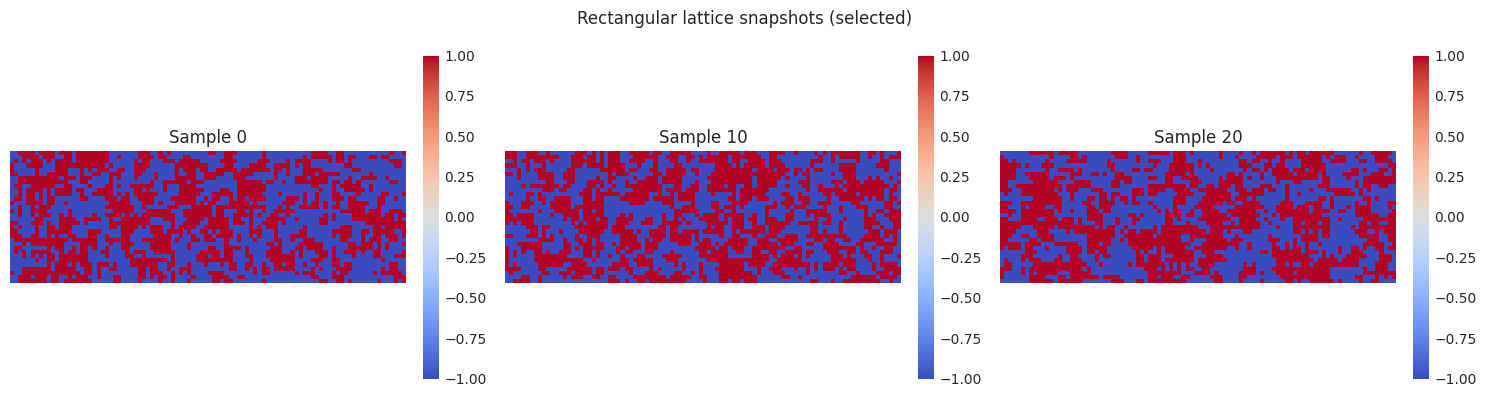

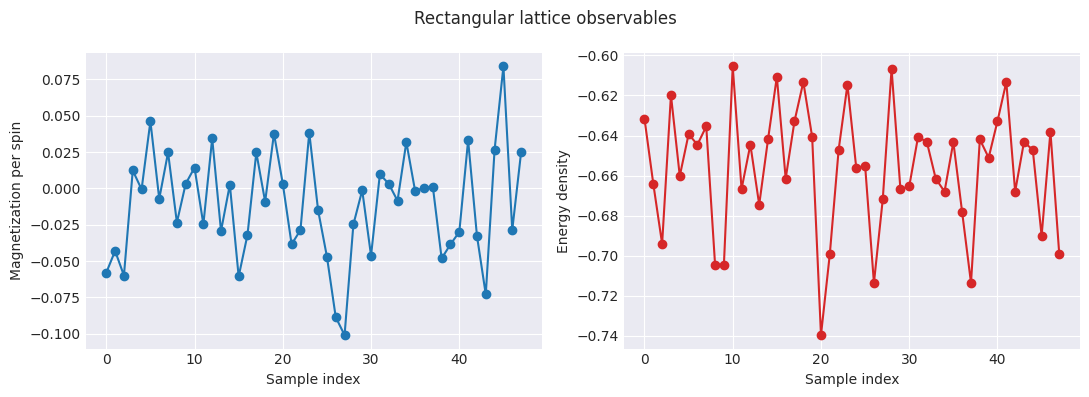

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
indices = [0, 10, 20]
for ax, idx in zip(axes, indices):
    visualize_spin_configuration(
        rectangular_run['snapshots'][idx],
        ax=ax,
        title=f'Sample {idx}'
    )
fig.suptitle('Rectangular lattice snapshots (selected)')
fig.tight_layout()
plt.show()

plot_observables(rectangular_run, suptitle='Rectangular lattice observables')
plt.show()


## Example 3: Higher-dimensional lattice
The simulator also accepts 3D (or higher) lattice shapes. While we cannot render higher-dimensional grids directly, magnetization and energy are still reported for every sample.

In [ ]:
volume_params = dict(
    lattice_shape=(12, 12, 6),
    temperature=4.0,
    n_samples=40,
    burn_in_sweeps=600,
    sweeps_per_sample=8,
    random_state=7,
)

volume_run = generate_ising_snapshots(**volume_params)
print('Snapshots shape:', volume_run['snapshots'].shape)
print('Magnetization range:', volume_run['magnetization'].min(), 'to', volume_run['magnetization'].max())
print('Energy density range:', volume_run['energy_density'].min(), 'to', volume_run['energy_density'].max())


## Direct simulator access
Use `IsingModelMetropolisSimulation` for lower-level control (custom update schedules, measurements, or coupling scans).

In [ ]:
sim = IsingModelMetropolisSimulation(
    lattice_shape=(48, 24),
    beta=1.0 / 2.5,
    J=1.0,
    h=0.0,
    random_state=123,
)

sim.sweep(300)
manual_snapshot = np.array(sim.to_numpy(sim.L))
print('Manual snapshot shape:', manual_snapshot.shape)
print('Magnetization now:', sim.magnetization())
print('Energy density now:', sim.energy_density())


## GPU-accelerated dataset export
Leverage CuPy (when available) to generate many Ising samples across a temperature grid and persist both flattened configurations and per-sample metadata (CSV) in the same style as the XY dataset notebooks. When you set `num_workers > 1`, the helper parallelizes across CPU processes (automatically falling back to NumPy even if `use_gpu=True`) while reporting progress in a per-temperature bar.

In [3]:
dataset_params = dict(
    temperatures=np.linspace(0.1, 3.5, 200),
    samples_per_temp=1,
    lattice_shape=(64, 64),
    burn_in_sweeps=600,
    sweeps_per_sample=12,
    J=1.0,
    h=0.0,
    use_gpu=True,
    seed=7,
    num_workers=4,
    show_progress=True,
)

outputs_dir = Path("./")
config_path = outputs_dir / "ising_model_configurations.npy"
metadata_path = outputs_dir / "ising_model_metadata.csv"


In [4]:
configs_flat, metadata_records = build_ising_dataset(**dataset_params)
configs_array = configs_flat.reshape(-1, *dataset_params['lattice_shape'])
metadata_df = pd.DataFrame(metadata_records)

print(f"Configurations array shape: {configs_array.shape}")
print(f"Metadata rows: {len(metadata_df)}")
print(metadata_df.head())

np.save(config_path, configs_array)
metadata_df.to_csv(metadata_path, index=False)
print(f"✓ Saved configurations to {config_path}")
print(f"✓ Saved metadata to {metadata_path}")


/workspace/Classifying-BLK-Transitions/XYModel/ising.py:205: RuntimeWarning: CuPy acceleration is only supported when num_workers=1; falling back to CPU for parallel execution.
  warnings.warn(


Temperatures:   0%|          | 0/200 [00:00<?, ?it/s]

Generated 200 samples across 200 temperatures in 32.82 minutes.
Configurations array shape: (200, 64, 64)
Metadata rows: 200
   temperature       beta  sample_idx  magnetization  energy_density  \
0     0.100000  10.000000           0       1.000000       -2.000000   
1     0.117085   8.540773           0       1.000000       -2.000000   
2     0.134171   7.453184           0       0.029785       -1.935547   
3     0.151256   6.611296           0       1.000000       -2.000000   
4     0.168342   5.940299           0       0.243164       -1.936523   

  lattice_shape    J    h  use_gpu  
0         64x64  1.0  0.0    False  
1         64x64  1.0  0.0    False  
2         64x64  1.0  0.0    False  
3         64x64  1.0  0.0    False  
4         64x64  1.0  0.0    False  
✓ Saved configurations to ising_model_configurations.npy
✓ Saved metadata to ising_model_metadata.csv


In [ ]:
metadata_df.groupby('temperature').agg({
    'magnetization': ['mean', 'std'],
    'energy_density': ['mean', 'std'],
}).round(3)


### Next steps
- Adjust `lattice_shape`, `temperature`, and sweep counts for the system you wish to study.
- Persist `square_run['snapshots']` (or similar) with `np.save` / `np.savez` for downstream ML tasks.
- Couple this generator to the existing BLT dataset tooling by swapping in Ising snapshots wherever XY samples are currently loaded.